In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [5]:
df = pd.read_csv(r"C:\Users\VIJAY K G\OneDrive\Documents\VIJAY K G\Python with harry\Python\Customer_churn_dataset.csv")
df.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,2,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,3,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,4,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,5,53,Female,58,24,9,2,Standard,Annual,533,18,0


In [5]:
df.isnull().sum()

CustomerID           0
Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     0
Churn                0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 64374 entries, 0 to 64373
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   CustomerID         64374 non-null  int64
 1   Age                64374 non-null  int64
 2   Gender             64374 non-null  str  
 3   Tenure             64374 non-null  int64
 4   Usage Frequency    64374 non-null  int64
 5   Support Calls      64374 non-null  int64
 6   Payment Delay      64374 non-null  int64
 7   Subscription Type  64374 non-null  str  
 8   Contract Length    64374 non-null  str  
 9   Total Spend        64374 non-null  int64
 10  Last Interaction   64374 non-null  int64
 11  Churn              64374 non-null  int64
dtypes: int64(9), str(3)
memory usage: 5.9 MB


In [11]:
df.describe()

,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000
mean,32187.500000,41.970982,31.994827,15.080234,5.400690,17.133952,541.023379,15.498850,0.473685
std,18583.317451,13.924911,17.098234,8.816470,3.114005,8.852211,260.874809,8.638436,0.499311
min,1.000000,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000,0.000000
25%,16094.250000,30.000000,18.000000,7.000000,3.000000,10.000000,313.000000,8.000000,0.000000
50%,32187.500000,42.000000,33.000000,15.000000,6.000000,19.000000,534.000000,15.000000,0.000000
75%,48280.750000,54.000000,47.000000,23.000000,8.000000,25.000000,768.000000,23.000000,1.000000
max,64374.000000,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000,1.000000


In [13]:
df.columns

Index(['CustomerID', 'Age', 'Gender', 'Tenure', 'Usage Frequency',
       'Support Calls', 'Payment Delay', 'Subscription Type',
       'Contract Length', 'Total Spend', 'Last Interaction', 'Churn'],
      dtype='str')

In [22]:
df.count()

CustomerID           64374
Age                  64374
Gender               64374
Tenure               64374
Usage Frequency      64374
Support Calls        64374
Payment Delay        64374
Subscription Type    64374
Contract Length      64374
Total Spend          64374
Last Interaction     64374
Churn                64374
dtype: int64

In [28]:
df["CustomerID"].nunique()

64374

In [27]:
df.isna().sum()

CustomerID           0
Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     0
Churn                0
dtype: int64

In [30]:
df.shape

(64374, 12)

In [33]:
avg_total_spend = (df.groupby("Subscription Type")["Total Spend"].mean())
avg_total_spend

Subscription Type
Basic       540.908536
Premium     543.581579
Standard    538.589387
Name: Total Spend, dtype: float64

In [40]:
df["Total Spend"].mean()

np.float64(541.0233790039457)

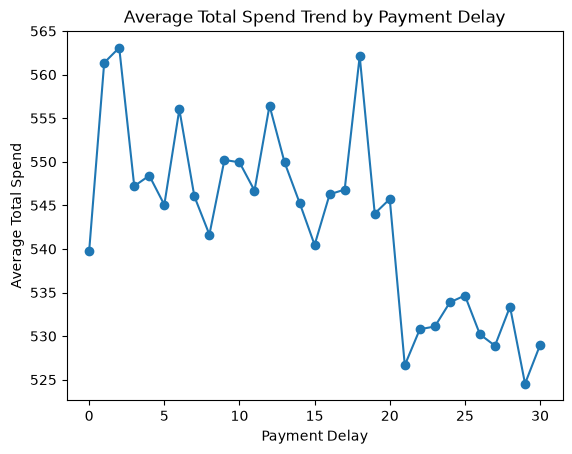

In [52]:
# PLOT CHART 
trend = df.groupby("Payment Delay")["Total Spend"].mean().reset_index()

plt.plot(trend["Payment Delay"], trend["Total Spend"], marker="o")

plt.xlabel("Payment Delay")
plt.ylabel("Average Total Spend")
plt.title("Average Total Spend Trend by Payment Delay")
plt.show()

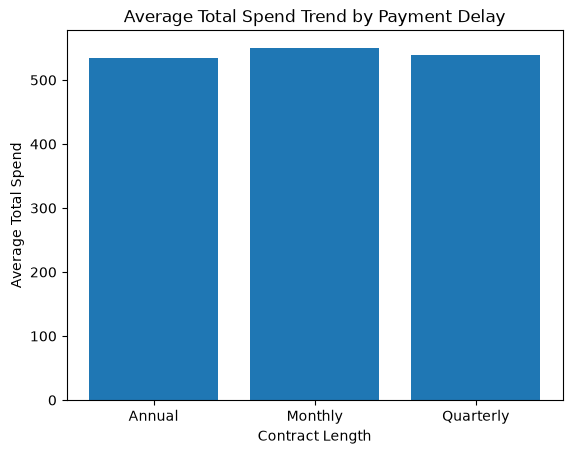

In [61]:
# BAR CHART
trend = df.groupby("Contract Length")["Total Spend"].mean().reset_index()

plt.bar(trend["Contract Length"], trend["Total Spend"].values)

plt.xlabel("Contract Length")
plt.ylabel("Average Total Spend")
plt.title("Average Total Spend Trend by Payment Delay")
plt.show()

<Axes: xlabel='Subscription Type', ylabel='Total Spend'>

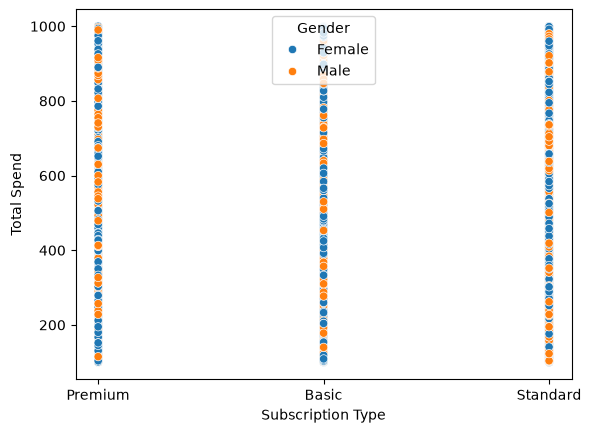

In [93]:
# SCATTER PLOT
sns.scatterplot(data = df,
               x = "Subscription Type",
               y = "Total Spend",
               hue = "Gender")

<Axes: >

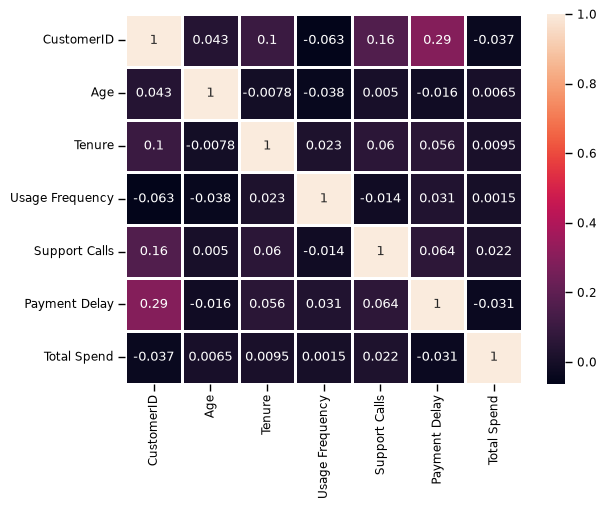

In [104]:
# HEAT MAP(for numeric values)
numeric_coln = ['CustomerID', 'Age', 'Tenure', 'Usage Frequency','Support Calls', 'Payment Delay', 'Total Spend']
sns.set_context("paper")
sns.heatmap(data = df[numeric_coln].corr(),
           annot = True,
           linewidth = 2)

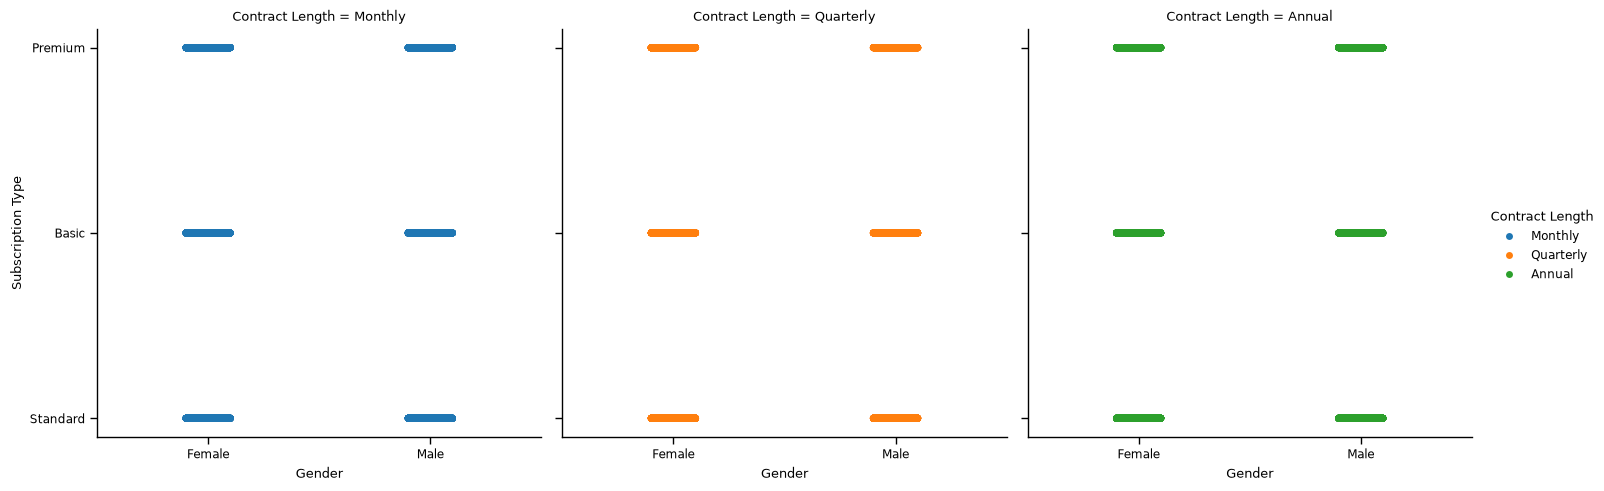

In [113]:
# CAT PLOT(string values)
sns.catplot(data = df,
            x = "Gender",
            y = "Subscription Type", 
            hue = "Contract Length",
           col = "Contract Length")

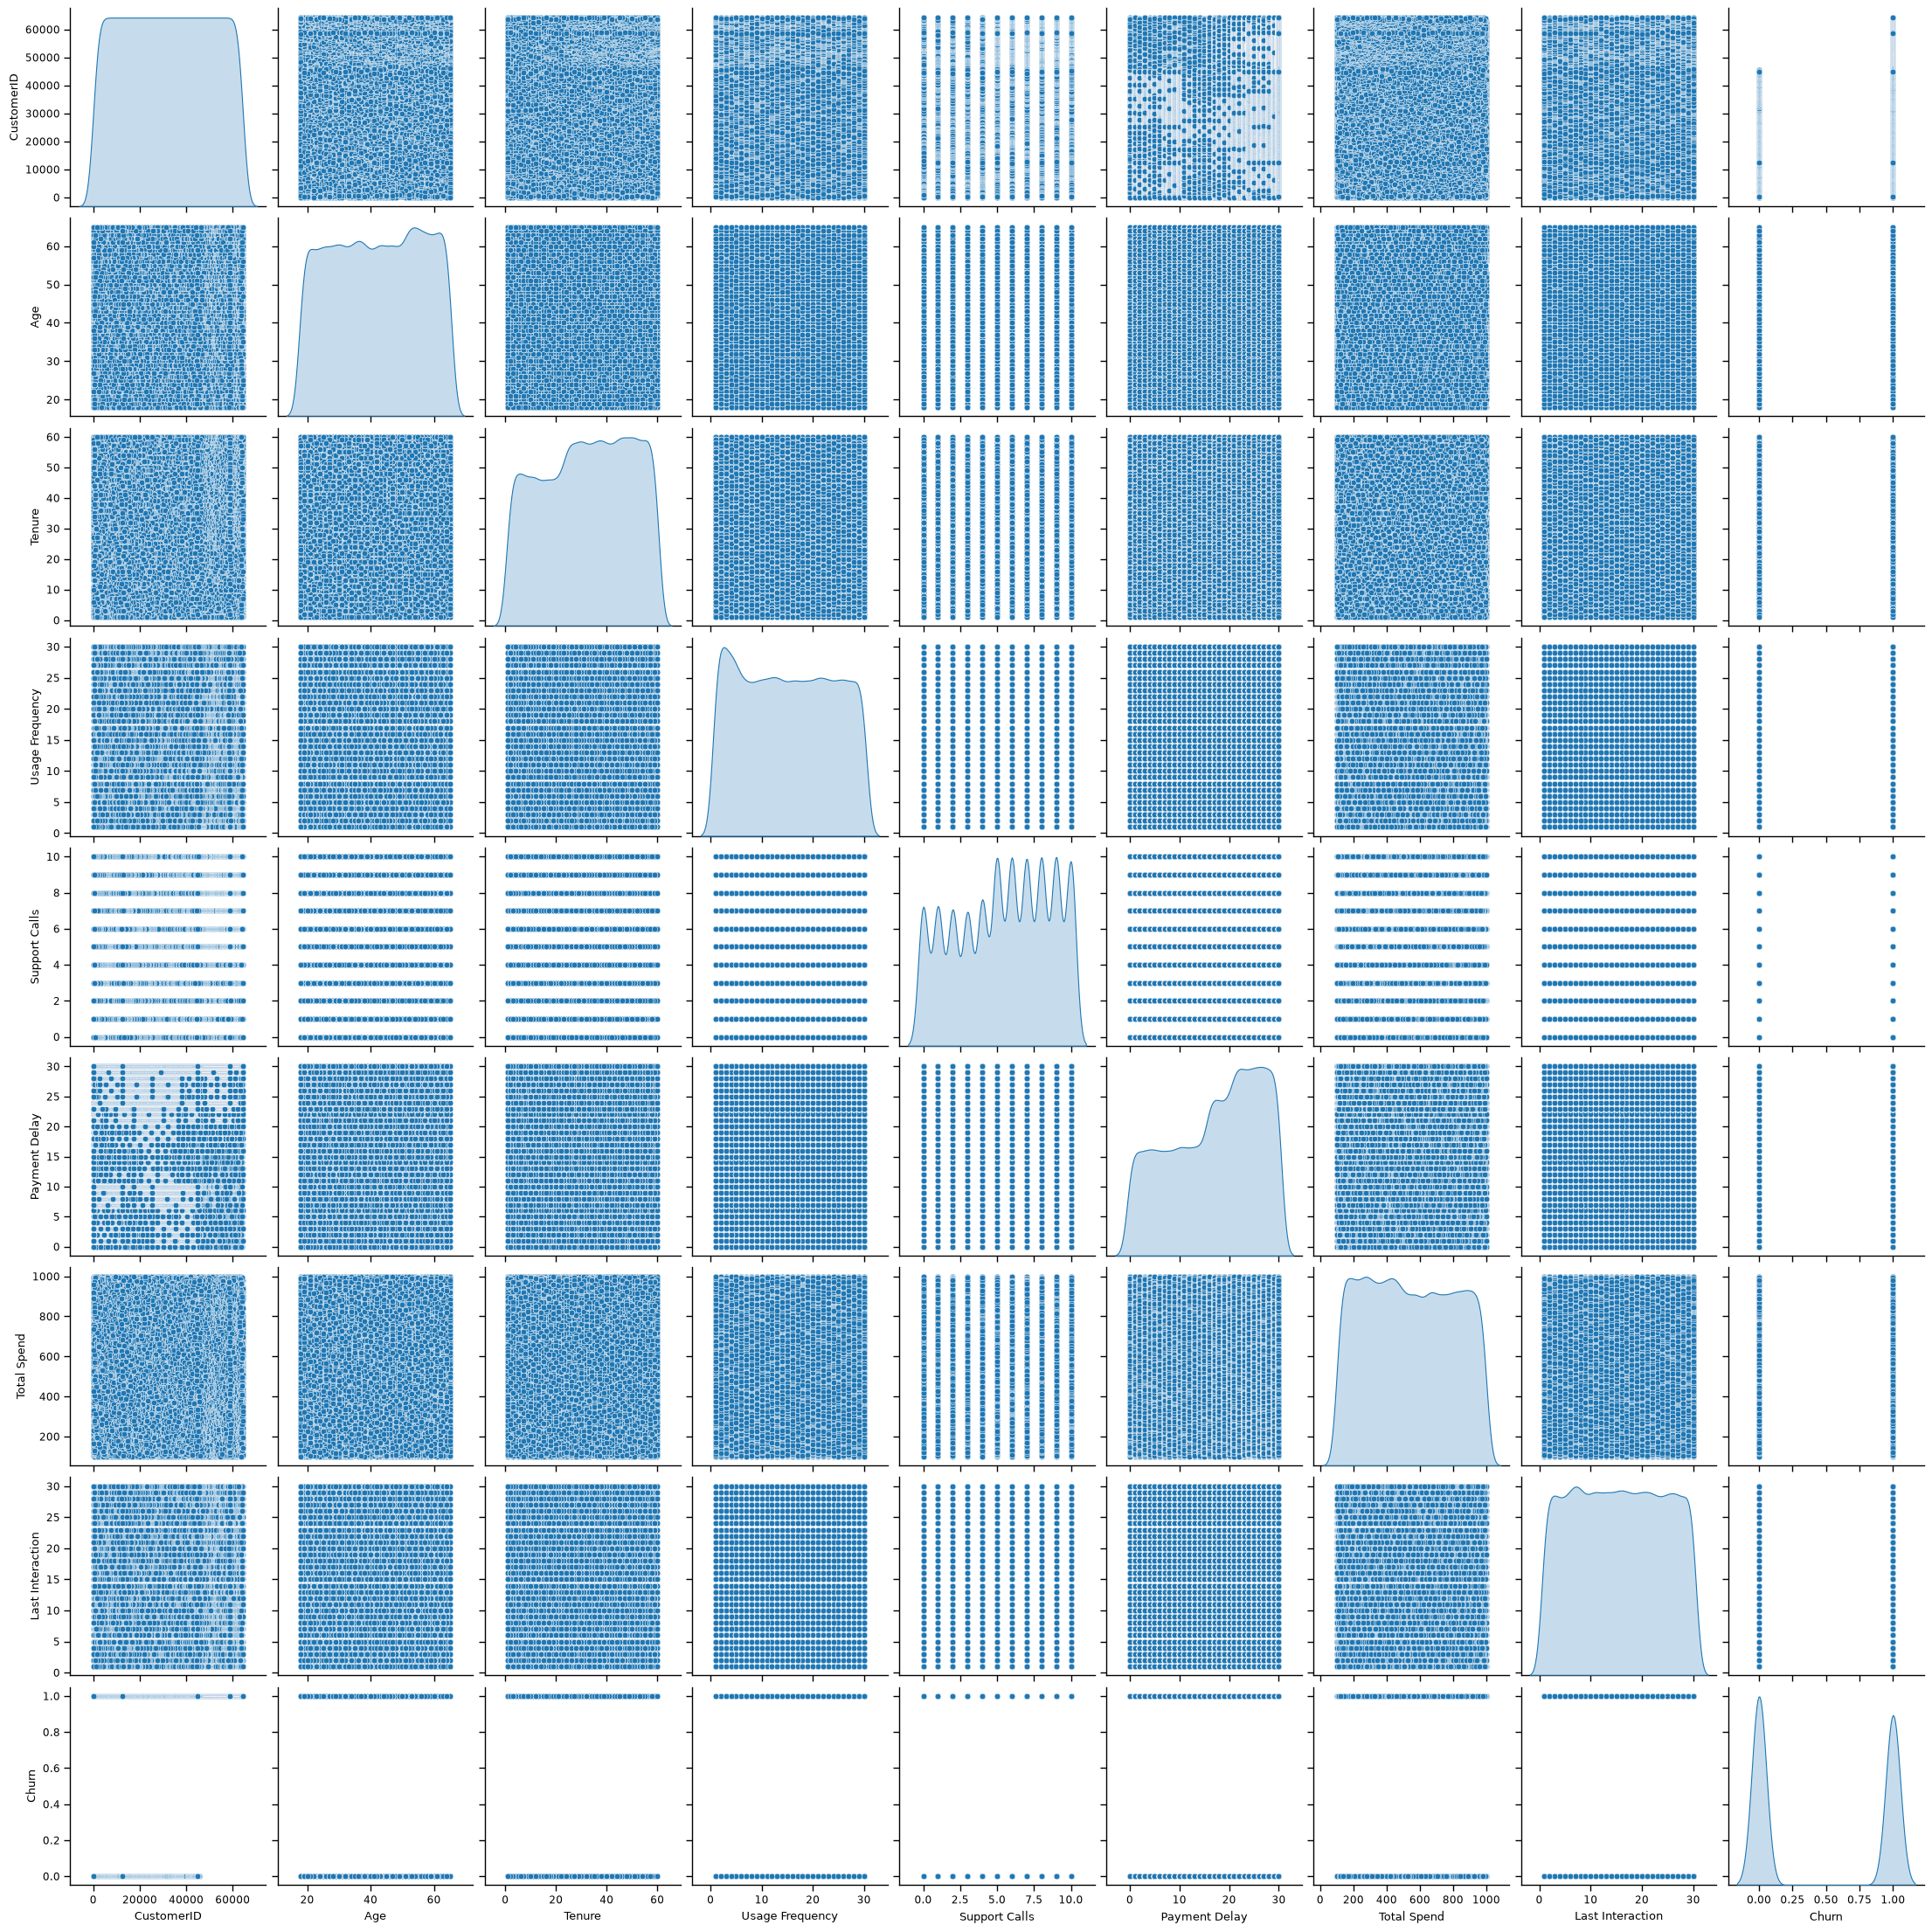

In [115]:
# PAIR PLOT
sns.pairplot(data = df, diag_kind = "kde")

In [7]:
# PIVOT TABLE
pd.pivot_table(data = df, 
               index = "Subscription Type",
               values = ['CustomerID', 'Tenure', 'Usage Frequency', 'Payment Delay', 'Total Spend'],
               aggfunc = {'CustomerID' : "count",
                         'Tenure' : "max",
                         'Usage Frequency' : "min",
                         'Payment Delay' : "mean", 
                         'Total Spend' : "sum"})

,CustomerID,Payment Delay,Tenure,Total Spend,Usage Frequency
Subscription Type,,,,,
Basic,21451,17.175237,60,11603029,1
Premium,21421,17.084076,60,11644061,1
Standard,21502,17.142452,60,11580749,1
